[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework1.ipynb)


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits import mplot3d

In [2]:
source = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/refs/heads/master/PCA_three_clusters_data.csv"
clusters = pd.read_csv(source)
clusters.head(10)

,x,y,z,class
0,0.647689,-0.138264,3.512299,0
1,-0.234137,-0.234153,10.769447,0
2,-0.469474,0.767435,11.166721,0
3,-0.465730,-0.463418,3.836479,0
4,-1.724918,-1.913280,1.710932,0
5,0.314247,-1.012831,-3.975973,0
6,1.465649,-1.412304,-6.420700,0
7,-1.424748,0.067528,-1.596480,0
8,-1.150994,0.110923,-3.849367,0
9,-0.291694,-0.600639,2.656586,0


# Firstly, we perform PCA on the 'clusters' data and plot it to check if it successfully clusters our data.

In [3]:
scaler = StandardScaler()

data = clusters[['x', 'y', 'z']]
data = scaler.fit_transform(data)

n_components = 2
pca = PCA(n_components = n_components)
pca_data = pca.fit_transform(data)


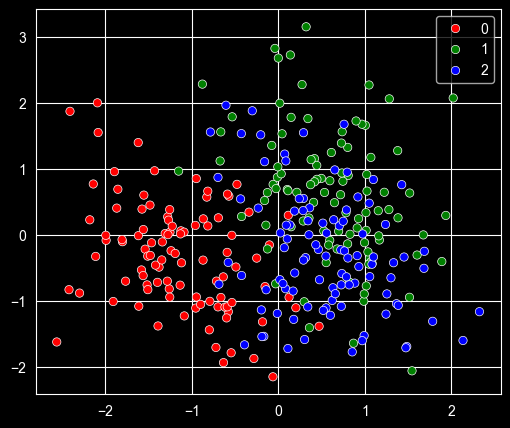

In [4]:
palette = {
    0: "red",
    1: "green",
    2: "blue"
}
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=pca_data[:, 0],
    y=pca_data[:, 1],
    hue=clusters["class"].to_numpy(),
    palette = palette
)
plt.show()

# The effects did not satisfy us enough, so we are projecting our data to "XY", "XZ" and "YZ" planes to check if this does a better job.

Text(0.5, 1.0, "Comparison of 'y' and 'z' features")

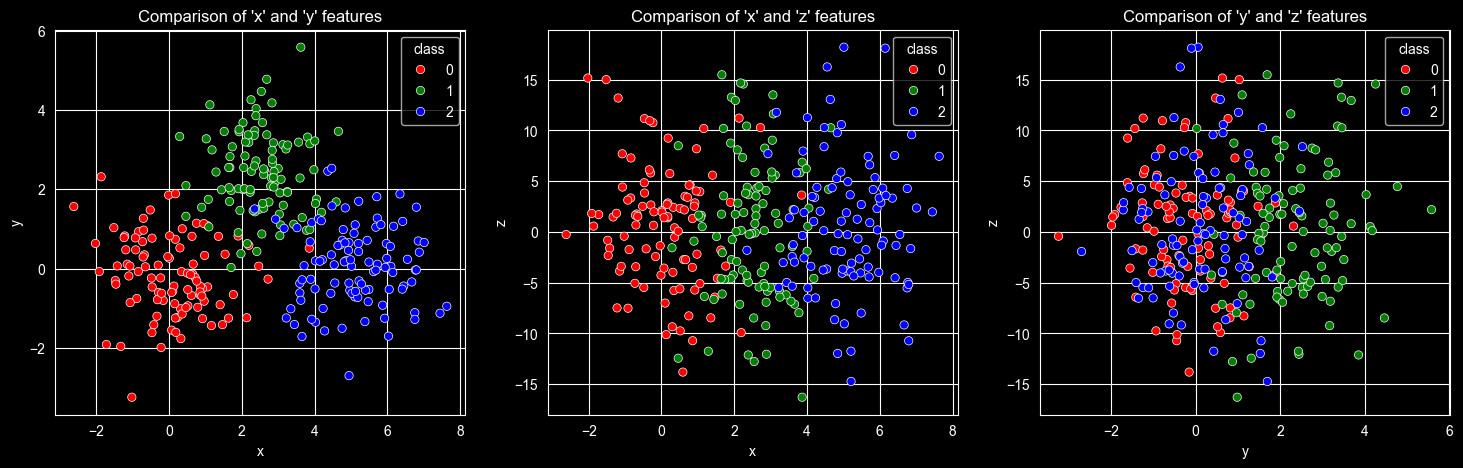

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {
    0: "red",
    1: "green",
    2: "blue"
}

sns.scatterplot(
    data = clusters,
    x = "x",
    y = "y",
    hue = "class",
    ax = axes[0],
    palette = palette
)
axes[0].set_title("Comparison of 'x' and 'y' features")

sns.scatterplot(
    data = clusters,
    x = "x",
    y = "z",
    hue = "class",
    palette = palette,
    ax = axes[1]
)
axes[1].set_title("Comparison of 'x' and 'z' features")

sns.scatterplot(
    data = clusters,
    x = "y",
    y = "z",
    hue = "class",
    palette = palette,
    ax = axes[2]
)
axes[2].set_title("Comparison of 'y' and 'z' features")

# Approach to solve the problem
Our data is three dimensional, so we try to visualize it to see why projection on 'xy' plane does better job than PCA

In [8]:
new_x = (clusters.x - clusters.x.mean())/(clusters.x.std())
new_y = (clusters.y - clusters.y.mean())/(clusters.y.std())
new_z = (clusters.z - clusters.z.mean())/(clusters.z.std())
standard_data = pd.DataFrame({
    "x": new_x,
    "y": new_y,
    "z": new_z,
    "class": clusters["class"].to_numpy()
})
%matplotlib notebook
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
palette = {
    0: "red",
    1: "green",
    2: "blue"
}
point_colors = clusters["class"].map(palette)
ax.scatter3D(standard_data.x, standard_data.y, standard_data.z, c = point_colors)
plt.title("Class of an object depending on 'x', 'y' and 'z' features")
plt.show()

<IPython.core.display.Javascript object>

# Conclusion
From the 3D visualization we can see that the clusters are mainly separated by 'xy' plane, although the data is dispersed along z-axis within each class. PCA algorithm, which looks only on data, not on classes, would rather point out directions with large spread than 'xy' direction, because it is looking for directions with maximal variance.

# Question two
When performing PCA, we want to distinguish clusters by looking for the directions in our data, which have the largest variance. If the data is not standardized before performing an algorithm, PCA may select meaningless direction because it focuses more on the features, which have the largest numerical values. For example, if we have a feature with small variance, but it is measured in milions, PCA would choose it over a feature, which has large variance, but it is measured in dozens.